# Windowed K-mer Transformer Experiment

Train a **Transformer** over windowed k-mer profiles on unlabeled paired reads from `train_2m.csv`,
then evaluate against all existing models on `reference/binning_5.tsv`.

**Hypothesis**: Splitting each 10kb read into windows and processing the sequence of local k-mer
profiles through a transformer captures positional composition patterns that the bag-of-k-mers
approach (NonLinear) discards.

| Model | Architecture | Uncertainty | Training |
|-------|-------------|-------------|----------|
| **NonLinear** | FF (256->512->256) | none | contrastive (bern) |
| **Transformer** | Windowed k-mer -> TransformerEncoder -> pool | none / Gaussian | contrastive (bern) |
| **Transformer+Var** | same | cross-window variance | contrastive (bern) |
| **Hinge** | FF (256->512->256) | none | contrastive (hinge) |
| **Bern-NT** | FF (256->512->256) | none | contrastive (bern, neg_threshold) |
| **UncertainGen** | FF + variance head | aleatoric (Gaussian) | Phase 2 variance |
| **PCL** | FF + kappa head | aleatoric (vMF) | MCInfoNCE |
| **LLA** | FF + Laplace | epistemic | KFAC post-hoc |

In [1]:
import sys, os, csv
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from functools import partial

from features.kmer import KmerFeatureExtractor
from embedders.nonlinear import NonLinearEmbedder, contrastive_loss, set_seed
from embedders.transformer import TransformerEmbedder
from embedders.pcl import PCLEmbedder, train_pcl
from embedders.uncertaingen import UncertainGenEmbedder, train_variance_phase
from embedders.laplace_embedder import LaplaceLastLayerEmbedder
from embedders.base import EmbeddingResult
from datasets.paired_reads import PairedReadsDataset
from train import train_contrastive
from clustering.kmedoid import KMedoidClusterer
from evaluation.eval_utils import (
    align_labels_via_hungarian_algorithm,
    count_high_quality_clusters,
    compute_class_center_medium_similarity,
)
import sklearn.metrics
from sklearn.model_selection import train_test_split

# -- Reproducibility --
SEED = 26042024
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# -- Data paths --
TRAIN_CSV = '../../data/dnabert/train/train_2m.csv'
TEST_TSV  = '../../data/dnabert/eval/reference/binning_5.tsv'

# -- Model output directory --
MODEL_DIR = '../../models/notebook/transformer_exp'
os.makedirs(MODEL_DIR, exist_ok=True)

# -- Training hyperparameters --
K           = 4
DIM         = 256
MAX_PAIRS   = 20_000

# NonLinear baseline
NL_EPOCHS      = 300
NL_LR          = 0.001
NL_BATCH_SIZE  = 256
NL_NEG_PER_POS = 20
NL_LOSS        = 'bern'

# Transformer
TF_WINDOW_SIZE     = 500
TF_D_MODEL         = 256
TF_NHEAD           = 4
TF_NUM_LAYERS      = 2
TF_DIM_FEEDFORWARD = 512
TF_DROPOUT         = 0.1
TF_EPOCHS          = 300
TF_LR              = 0.001
TF_BATCH_SIZE      = 256
TF_NEG_PER_POS     = 20
TF_LOSS            = 'bern'

# Bern-NT
BERN_NT_EPOCHS     = 300
BERN_NT_LR         = 0.001
BERN_NT_BATCH_SIZE = 256
BERN_NT_LOSS       = 'bern'
BERN_NT_NEG_THRESH = -1.0

# UncertainGen Phase 2
UG_EPOCHS_P2     = 200
UG_LR_P2         = 0.001
UG_BATCH_SIZE_P2 = 256
UG_ALPHA         = 1.0
UG_K_FORM        = 'identity'

# PCL
PCL_LR                   = 0.001
PCL_BATCH_SIZE           = 512
PCL_N_BATCHES_HALF_PHASE = 10_000
PCL_N_MC_SAMPLES         = 8
PCL_LOSS_KAPPA_INIT      = 16.0
PCL_NEG_PER_POS          = 32

# Evaluation
METRIC         = 'l2'
MIN_BIN_SIZE   = 5
NUM_WORKERS    = 0   # required on Windows

print(f'Device: {DEVICE}')
print(f'Model dir: {MODEL_DIR}')

Device: cuda
Model dir: ../../models/notebook/transformer_exp


## 1. Training Data

Load ~20K unlabeled read pairs. Create **two** datasets:
- Standard (bag-of-k-mers) for NonLinear / baselines
- Windowed (sequence of local k-mer profiles) for Transformer

In [2]:
set_seed(SEED)

feature_extractor = KmerFeatureExtractor(k=K, normalized=True)

# Standard dataset (bag-of-k-mers) for NonLinear and baselines
train_dataset = PairedReadsDataset(
    file_path=TRAIN_CSV,
    transform_func=feature_extractor.extract,
    neg_sample_per_pos=NL_NEG_PER_POS,
    max_read_num=MAX_PAIRS,
    seed=SEED,
    verbose=True,
)
print(f'Standard dataset: {len(train_dataset)} pairs, profile shape: {train_dataset._all_profiles.shape}')

# Windowed dataset for Transformer
def windowed_transform(seq):
    return feature_extractor.extract_windowed(seq, window_size=TF_WINDOW_SIZE)

train_dataset_windowed = PairedReadsDataset(
    file_path=TRAIN_CSV,
    transform_func=windowed_transform,
    neg_sample_per_pos=TF_NEG_PER_POS,
    max_read_num=MAX_PAIRS,
    seed=SEED,
    verbose=True,
)
print(f'Windowed dataset: {len(train_dataset_windowed)} pairs, profile shape: {train_dataset_windowed._all_profiles.shape}')

 Counting lines: 2,000,000 lines (cached)


 Loading read pairs │██████████████████████████████│ 20000/20000 [03:45<00:00]


Dataset loaded: 20000 read pairs from 2000000 total lines.
Standard dataset: 20000 pairs, profile shape: torch.Size([40000, 256])
 Counting lines: 2,000,000 lines (cached)


 Loading read pairs │██████████████████████████████│ 20000/20000 [03:40<00:00]


Dataset loaded: 20000 read pairs from 2000000 total lines.
Windowed dataset: 20000 pairs, profile shape: torch.Size([40000, 20, 256])


## 2. Train NonLinear Baseline

Deterministic contrastive baseline with Bernoulli loss (same as other experiment notebooks).

In [3]:
NL_PATH      = os.path.join(MODEL_DIR, 'nonlinear_unlabeled.model')
NL_LOSS_PATH = os.path.join(MODEL_DIR, 'nonlinear_unlabeled_losses.npy')

set_seed(SEED)

if os.path.exists(NL_PATH):
    model_nl = NonLinearEmbedder.load(NL_PATH, device=DEVICE)
    nl_losses = np.load(NL_LOSS_PATH) if os.path.exists(NL_LOSS_PATH) else None
    print(f'NonLinear loaded from {NL_PATH}')
else:
    print('Training NonLinear on unlabeled pairs...')
    model_nl = NonLinearEmbedder(k=K, dim=DIM, device=DEVICE, seed=SEED)

    nl_losses = train_contrastive(
        model_nl, train_dataset,
        loss_fn=contrastive_loss,
        lr=NL_LR,
        epochs=NL_EPOCHS,
        device=DEVICE,
        batch_size=NL_BATCH_SIZE,
        num_workers=NUM_WORKERS,
        loss_name=NL_LOSS,
        save_path=NL_PATH,
        verbose=True,
    )
    nl_losses = np.array(nl_losses)
    np.save(NL_LOSS_PATH, nl_losses)
    print(f'NonLinear saved. Final loss: {nl_losses[-1]:.4f}')

print(f'NonLinear params: {sum(p.numel() for p in model_nl.parameters()):,}')

NonLinear loaded from ../../models/notebook/transformer_exp\nonlinear_unlabeled.model
NonLinear params: 263,936


## 3. Train Transformer (deterministic)

Windowed k-mer profiles -> TransformerEncoder -> mean pooling -> contrastive (bern).
Same training data, same loss, same hyperparameters -- only the model architecture changes.

In [4]:
TF_PATH      = os.path.join(MODEL_DIR, 'transformer_unlabeled.model')
TF_LOSS_PATH = os.path.join(MODEL_DIR, 'transformer_unlabeled_losses.npy')

set_seed(SEED)

if os.path.exists(TF_PATH):
    model_tf = TransformerEmbedder.load(TF_PATH, device=DEVICE)
    tf_losses = np.load(TF_LOSS_PATH) if os.path.exists(TF_LOSS_PATH) else None
    print(f'Transformer loaded from {TF_PATH}')
else:
    print('Training Transformer on unlabeled pairs...')
    model_tf = TransformerEmbedder(
        k=K, dim=DIM, window_size=TF_WINDOW_SIZE,
        d_model=TF_D_MODEL, nhead=TF_NHEAD, num_layers=TF_NUM_LAYERS,
        dim_feedforward=TF_DIM_FEEDFORWARD, dropout=TF_DROPOUT,
        output_variance=False,
        device=DEVICE, seed=SEED,
    )

    tf_losses = train_contrastive(
        model_tf, train_dataset_windowed,
        loss_fn=contrastive_loss,
        lr=TF_LR,
        epochs=TF_EPOCHS,
        device=DEVICE,
        batch_size=TF_BATCH_SIZE,
        num_workers=NUM_WORKERS,
        loss_name=TF_LOSS,
        save_path=TF_PATH,
        verbose=True,
    )
    tf_losses = np.array(tf_losses)
    np.save(TF_LOSS_PATH, tf_losses)
    print(f'Transformer saved. Final loss: {tf_losses[-1]:.4f}')

print(f'Transformer params: {sum(p.numel() for p in model_tf.parameters()):,}')

Transformer loaded from ../../models/notebook/transformer_exp\transformer_unlabeled.model
Transformer params: 1,136,384


## 3b. Train Transformer+Var (with cross-window uncertainty)

Same architecture but `output_variance=True`. The variance is derived from
cross-window disagreement in the transformer outputs -- no separate training phase needed.

In [5]:
TF_VAR_PATH      = os.path.join(MODEL_DIR, 'transformer_var_unlabeled.model')
TF_VAR_LOSS_PATH = os.path.join(MODEL_DIR, 'transformer_var_unlabeled_losses.npy')

set_seed(SEED)

if os.path.exists(TF_VAR_PATH):
    model_tf_var = TransformerEmbedder.load(TF_VAR_PATH, device=DEVICE)
    tf_var_losses = np.load(TF_VAR_LOSS_PATH) if os.path.exists(TF_VAR_LOSS_PATH) else None
    print(f'Transformer+Var loaded from {TF_VAR_PATH}')
else:
    print('Training Transformer+Var on unlabeled pairs...')
    model_tf_var = TransformerEmbedder(
        k=K, dim=DIM, window_size=TF_WINDOW_SIZE,
        d_model=TF_D_MODEL, nhead=TF_NHEAD, num_layers=TF_NUM_LAYERS,
        dim_feedforward=TF_DIM_FEEDFORWARD, dropout=TF_DROPOUT,
        output_variance=True,
        device=DEVICE, seed=SEED,
    )

    tf_var_losses = train_contrastive(
        model_tf_var, train_dataset_windowed,
        loss_fn=contrastive_loss,
        lr=TF_LR,
        epochs=TF_EPOCHS,
        device=DEVICE,
        batch_size=TF_BATCH_SIZE,
        num_workers=NUM_WORKERS,
        loss_name=TF_LOSS,
        save_path=TF_VAR_PATH,
        verbose=True,
    )
    tf_var_losses = np.array(tf_var_losses)
    np.save(TF_VAR_LOSS_PATH, tf_var_losses)
    print(f'Transformer+Var saved. Final loss: {tf_var_losses[-1]:.4f}')

print(f'Transformer+Var params: {sum(p.numel() for p in model_tf_var.parameters()):,}')

Training Transformer+Var on unlabeled pairs...


 Training │██████████████████████████████│ 300/300 [2:49:42<00:00, loss=0.024145]  

Model saved to: ../../models/notebook/transformer_exp\transformer_var_unlabeled.model
Transformer+Var saved. Final loss: 0.0241
Transformer+Var params: 1,202,176


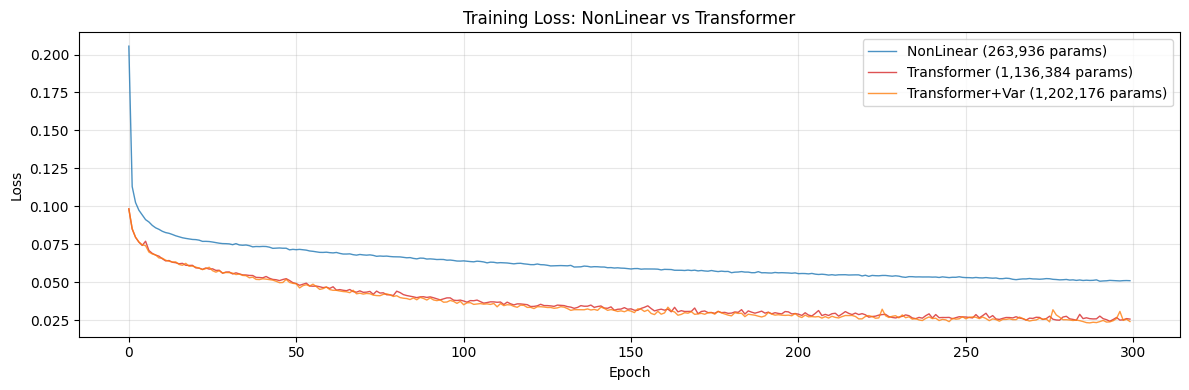

  NonLinear: final=0.0510, min=0.0507
  Transformer: final=0.0257, min=0.0243
  Transformer+Var: final=0.0241, min=0.0232


In [6]:
# -- Training loss comparison --
fig, ax = plt.subplots(figsize=(12, 4))
if nl_losses is not None:
    ax.plot(nl_losses, lw=1, color='tab:blue', alpha=0.8, label=f'NonLinear ({sum(p.numel() for p in model_nl.parameters()):,} params)')
if tf_losses is not None:
    ax.plot(tf_losses, lw=1, color='tab:red', alpha=0.8, label=f'Transformer ({sum(p.numel() for p in model_tf.parameters()):,} params)')
if tf_var_losses is not None:
    ax.plot(tf_var_losses, lw=1, color='tab:orange', alpha=0.8, label=f'Transformer+Var ({sum(p.numel() for p in model_tf_var.parameters()):,} params)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss: NonLinear vs Transformer')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for name, losses in [('NonLinear', nl_losses), ('Transformer', tf_losses), ('Transformer+Var', tf_var_losses)]:
    if losses is not None:
        print(f'  {name}: final={losses[-1]:.4f}, min={losses.min():.4f}')

## 4. Train Baselines (Bern-NT, UncertainGen, PCL, LLA)

Reuse existing model training patterns from other experiment notebooks.

In [7]:
# -- Bern-NT --
BERN_NT_PATH      = os.path.join(MODEL_DIR, 'bern_nt_unlabeled.model')
BERN_NT_LOSS_PATH = os.path.join(MODEL_DIR, 'bern_nt_unlabeled_losses.npy')

set_seed(SEED)
if os.path.exists(BERN_NT_PATH):
    model_bern_nt = NonLinearEmbedder.load(BERN_NT_PATH, device=DEVICE)
    bern_nt_losses = np.load(BERN_NT_LOSS_PATH) if os.path.exists(BERN_NT_LOSS_PATH) else None
    print(f'Bern-NT loaded from {BERN_NT_PATH}')
else:
    print('Training Bern-NT...')
    model_bern_nt = NonLinearEmbedder(k=K, dim=DIM, device=DEVICE, seed=SEED)
    bern_nt_losses = train_contrastive(
        model_bern_nt, train_dataset,
        loss_fn=partial(contrastive_loss, neg_threshold=BERN_NT_NEG_THRESH),
        lr=BERN_NT_LR, epochs=BERN_NT_EPOCHS, device=DEVICE,
        batch_size=BERN_NT_BATCH_SIZE, num_workers=NUM_WORKERS,
        loss_name=BERN_NT_LOSS, save_path=BERN_NT_PATH, verbose=True,
    )
    bern_nt_losses = np.array(bern_nt_losses)
    np.save(BERN_NT_LOSS_PATH, bern_nt_losses)
    print(f'Bern-NT saved. Final loss: {bern_nt_losses[-1]:.4f}')

# -- UncertainGen (Phase 2 from Bern-NT) --
UG_BNT_PATH      = os.path.join(MODEL_DIR, 'ug_bern_nt_unlabeled.model')
UG_BNT_LOSS_PATH = os.path.join(MODEL_DIR, 'ug_bern_nt_unlabeled_losses.npy')

set_seed(SEED)
if os.path.exists(UG_BNT_PATH):
    model_ug_bnt = UncertainGenEmbedder.load(UG_BNT_PATH, device=DEVICE)
    ug_bnt_losses = np.load(UG_BNT_LOSS_PATH) if os.path.exists(UG_BNT_LOSS_PATH) else None
    print(f'Bern-NT + UG loaded from {UG_BNT_PATH}')
else:
    print('Training Bern-NT + UG (Phase 2)...')
    model_ug_bnt = UncertainGenEmbedder(
        k=K, dim=DIM, alpha=UG_ALPHA, k_form=UG_K_FORM, device=DEVICE, seed=SEED,
    )
    model_ug_bnt.copy_mean_from(model_bern_nt)
    ug_bnt_losses = train_variance_phase(
        model_ug_bnt, train_dataset, lr=UG_LR_P2, epochs=UG_EPOCHS_P2,
        device=DEVICE, batch_size=UG_BATCH_SIZE_P2, num_workers=NUM_WORKERS,
        alpha=UG_ALPHA, verbose=True,
    )
    model_ug_bnt.save(UG_BNT_PATH)
    ug_bnt_losses = np.array(ug_bnt_losses)
    np.save(UG_BNT_LOSS_PATH, ug_bnt_losses)
    print(f'Bern-NT + UG saved. Final loss: {ug_bnt_losses[-1]:.4f}')

# -- PCL --
PCL_PATH      = os.path.join(MODEL_DIR, 'pcl_unlabeled.model')
PCL_LOSS_PATH = os.path.join(MODEL_DIR, 'pcl_unlabeled_losses.npy')

set_seed(SEED)
if os.path.exists(PCL_PATH):
    model_pcl = PCLEmbedder.load(PCL_PATH, device=DEVICE)
    pcl_losses = np.load(PCL_LOSS_PATH) if os.path.exists(PCL_LOSS_PATH) else None
    print(f'PCL loaded from {PCL_PATH}')
else:
    print('Training PCL...')
    pcl_dataset = PairedReadsDataset(
        file_path=TRAIN_CSV, transform_func=feature_extractor.extract,
        neg_sample_per_pos=PCL_NEG_PER_POS, max_read_num=MAX_PAIRS, seed=SEED, verbose=True,
    )
    model_pcl = PCLEmbedder(k=K, dim=DIM, device=DEVICE, seed=SEED, kappa_mode='implicit')
    model_pcl.copy_mean_from(model_nl)
    pcl_losses = train_pcl(
        model_pcl, pcl_dataset, lr=PCL_LR, device=DEVICE, batch_size=PCL_BATCH_SIZE,
        num_workers=NUM_WORKERS, n_phases=0, n_batches_per_half_phase=PCL_N_BATCHES_HALF_PHASE,
        n_mc_samples=PCL_N_MC_SAMPLES, loss_kappa_init=PCL_LOSS_KAPPA_INIT,
        save_path=PCL_PATH, verbose=True,
    )
    pcl_losses = np.array(pcl_losses)
    np.save(PCL_LOSS_PATH, pcl_losses)
    del pcl_dataset
    print(f'PCL saved. Final loss: {pcl_losses[-1]:.4f}')

# -- LLA --
LLA_PATH = os.path.join(MODEL_DIR, 'lla_state.pt')

model_lla = LaplaceLastLayerEmbedder(model_nl)
if os.path.exists(LLA_PATH):
    lla_state = torch.load(LLA_PATH, map_location=DEVICE, weights_only=True)
    model_lla.Q_A = lla_state['Q_A']
    model_lla.Q_B = lla_state['Q_B']
    model_lla.S_A = lla_state['S_A']
    model_lla.S_B = lla_state['S_B']
    model_lla.prior_precision = lla_state['prior_precision']
    model_lla.n_data = lla_state['n_data']
    model_lla._fitted = True
    print(f'LLA loaded from {LLA_PATH} (prior={model_lla.prior_precision:.2f})')
else:
    print('Fitting LLA...')
    model_lla.fit(
        dataset=train_dataset, loss_fn=contrastive_loss,
        batch_size=256, device=DEVICE, loss_name='bern',
        hessian_factorization='ggn', verbose=True,
    )
    model_lla.optimize_prior(method='mackay')
    torch.save({
        'Q_A': model_lla.Q_A, 'Q_B': model_lla.Q_B,
        'S_A': model_lla.S_A, 'S_B': model_lla.S_B,
        'prior_precision': model_lla.prior_precision,
        'n_data': model_lla.n_data,
    }, LLA_PATH)
    print(f'LLA saved. Prior: {model_lla.prior_precision:.4f}')

Bern-NT loaded from ../../models/notebook/transformer_exp\bern_nt_unlabeled.model
Bern-NT + UG loaded from ../../models/notebook/transformer_exp\ug_bern_nt_unlabeled.model
PCL loaded from ../../models/notebook/transformer_exp\pcl_unlabeled.model
LLA loaded from ../../models/notebook/transformer_exp\lla_state.pt (prior=4114.23)


## 5. Load Evaluation Data

Stratified 50/50 split of `reference/binning_5.tsv` into validation and test.

In [8]:
csv.field_size_limit(min(sys.maxsize, 2**31 - 1))

with open(TEST_TSV) as f:
    reader = csv.reader(f, delimiter='\t')
    _header = next(reader)
    all_rows = list(reader)

all_seqs       = [r[0] for r in all_rows]
all_labels_str = [r[1] for r in all_rows]

# Remove singleton classes
label_counts = Counter(all_labels_str)
singleton_classes = {l for l, c in label_counts.items() if c < 2}
if singleton_classes:
    print(f'Removing {len(singleton_classes)} singleton classes')
    keep = [(s, l) for s, l in zip(all_seqs, all_labels_str) if l not in singleton_classes]
    all_seqs       = [s for s, l in keep]
    all_labels_str = [l for s, l in keep]

# Stratified split
val_seqs, test_seqs, val_labels_str, test_labels_str = train_test_split(
    all_seqs, all_labels_str, test_size=0.5, random_state=SEED, stratify=all_labels_str)

unique_labels = sorted(set(all_labels_str))
lab2id        = {l: i for i, l in enumerate(unique_labels)}
n_species     = len(unique_labels)

val_labels_num = np.array([lab2id[l] for l in val_labels_str])
test_labels    = np.array([lab2id[l] for l in test_labels_str])

print(f'Loaded {len(all_rows)} sequences from reference/binning_5.tsv')
print(f'Validation: {len(val_seqs)} | Test: {len(test_seqs)} | Species: {n_species}')

Loaded 37278 sequences from reference/binning_5.tsv
Validation: 18639 | Test: 18639 | Species: 323


## 6. Embed All Sequences

Embed validation and test splits with all models.

In [9]:
print('Embedding validation...')
val_emb_nl      = model_nl.embed(val_seqs)
val_emb_tf      = model_tf.embed(val_seqs)
val_emb_tf_var  = model_tf_var.embed(val_seqs)
val_emb_bern_nt = model_bern_nt.embed(val_seqs)
val_emb_ug_bnt  = model_ug_bnt.embed(val_seqs)
val_emb_pcl     = model_pcl.embed(val_seqs)
val_emb_lla     = model_lla.embed(val_seqs)

print('Embedding test...')
test_emb_nl      = model_nl.embed(test_seqs)
test_emb_tf      = model_tf.embed(test_seqs)
test_emb_tf_var  = model_tf_var.embed(test_seqs)
test_emb_bern_nt = model_bern_nt.embed(test_seqs)
test_emb_ug_bnt  = model_ug_bnt.embed(test_seqs)
test_emb_pcl     = model_pcl.embed(test_seqs)
test_emb_lla     = model_lla.embed(test_seqs)

print(f'\n{"Model":<20} {"Val shape":>16} {"Test shape":>16} {"Var?":>6}')
print('-' * 62)
for name, ve, te in [
    ('NonLinear',      val_emb_nl,      test_emb_nl),
    ('Transformer',    val_emb_tf,      test_emb_tf),
    ('Transformer+Var',val_emb_tf_var,  test_emb_tf_var),
    ('Bern-NT',        val_emb_bern_nt, test_emb_bern_nt),
    ('Bern-NT + UG',   val_emb_ug_bnt,  test_emb_ug_bnt),
    ('PCL',            val_emb_pcl,     test_emb_pcl),
    ('LLA',            val_emb_lla,     test_emb_lla),
]:
    has_var = ve.variance is not None or ve.kappa is not None
    print(f'{name:<20} {str(ve.mean.shape):>16} {str(te.mean.shape):>16} {str(has_var):>6}')

Embedding validation...
Embedding test...

Model                       Val shape       Test shape   Var?
--------------------------------------------------------------
NonLinear                (18639, 256)     (18639, 256)  False
Transformer              (18639, 256)     (18639, 256)  False
Transformer+Var          (18639, 256)     (18639, 256)   True
Bern-NT                  (18639, 256)     (18639, 256)  False
Bern-NT + UG             (18639, 256)     (18639, 256)   True
PCL                      (18639, 256)     (18639, 256)   True
LLA                      (18639, 256)     (18639, 256)   True


## 7. t-SNE Visualization

Compare embedding spaces: NonLinear vs Transformer vs Transformer+Var vs baselines.

  t-SNE: NonLinear...
  t-SNE: Transformer...
  t-SNE: Transformer+Var...
  t-SNE: Bern-NT...
  t-SNE: Bern-NT + UG...
  t-SNE: PCL...


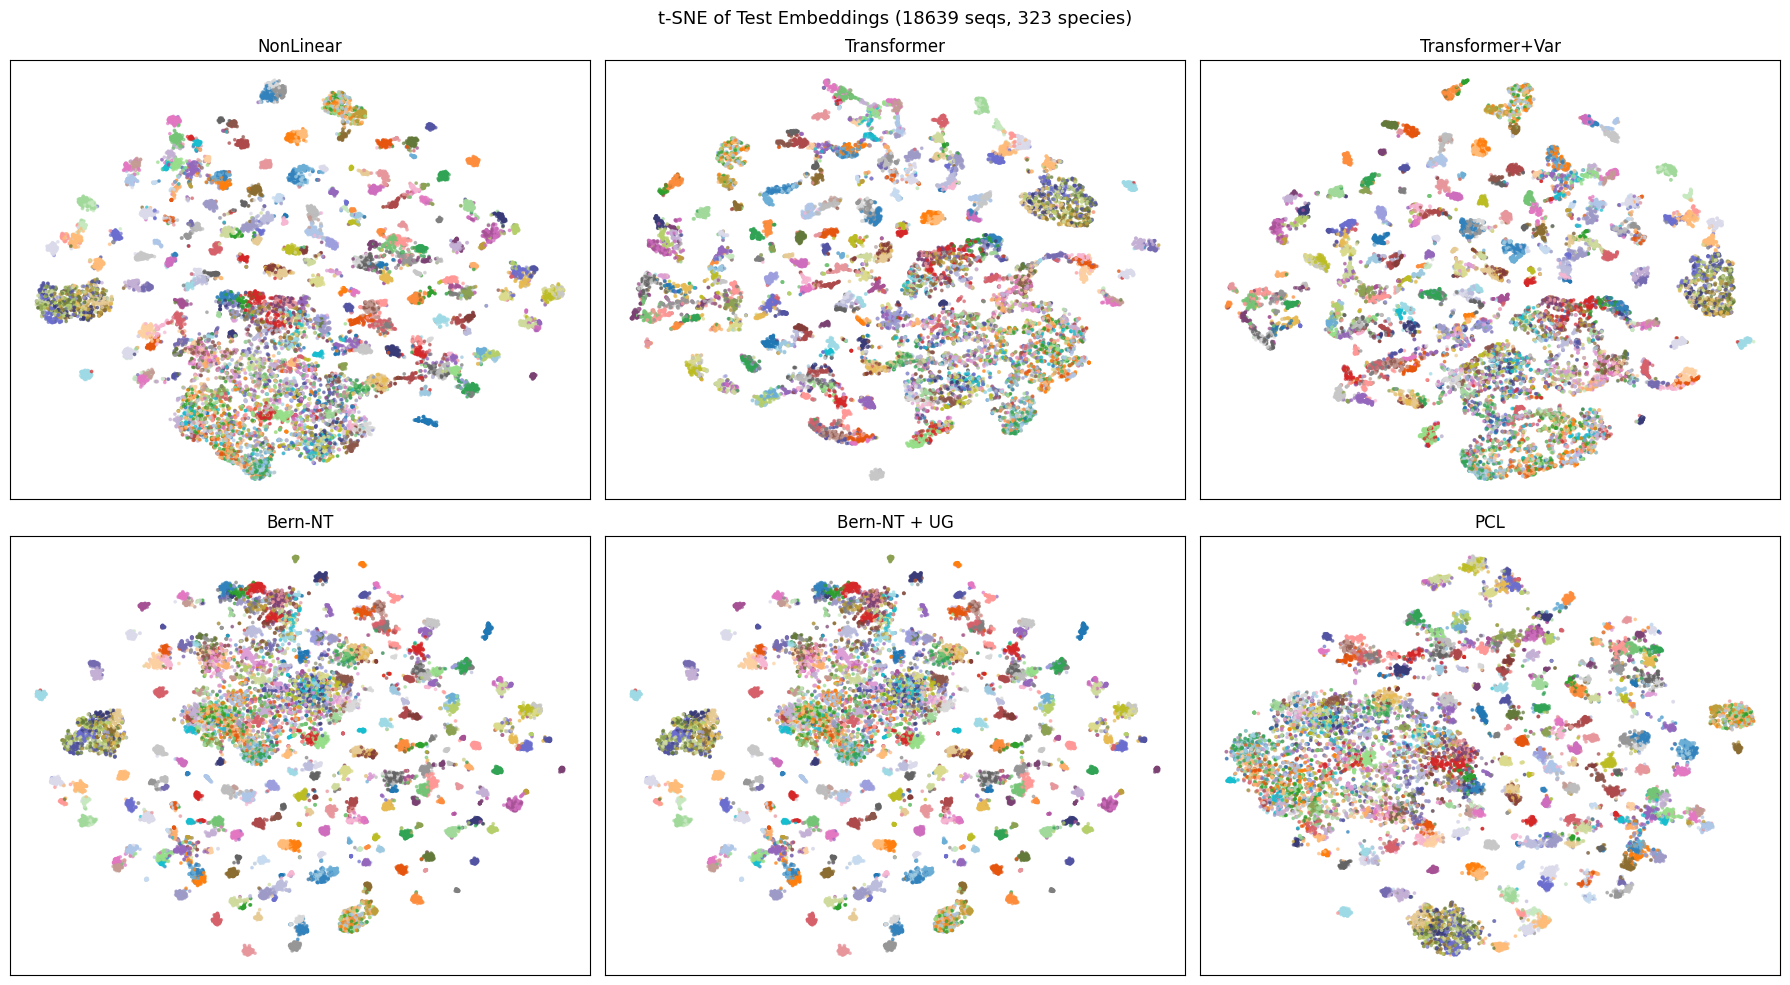

In [10]:
from sklearn.manifold import TSNE

# Species colors
_n_cls = n_species
_base = np.vstack([
    plt.cm.tab20(np.linspace(0, 1, 20)),
    plt.cm.tab20b(np.linspace(0, 1, 20)),
    plt.cm.tab20c(np.linspace(0, 1, 20)),
])
species_colors = np.tile(_base, (max(1, _n_cls // len(_base) + 1), 1))[:_n_cls]
test_colors = np.array([species_colors[l] for l in test_labels])

tsne_kw = dict(n_components=2, random_state=SEED, perplexity=30, max_iter=1000)
s, alpha = 3, 0.6

models_to_plot = [
    ('NonLinear',       test_emb_nl.mean),
    ('Transformer',     test_emb_tf.mean),
    ('Transformer+Var', test_emb_tf_var.mean),
    ('Bern-NT',         test_emb_bern_nt.mean),
    ('Bern-NT + UG',    test_emb_ug_bnt.mean),
    ('PCL',             test_emb_pcl.mean),
]

n_plots = len(models_to_plot)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, embs) in enumerate(models_to_plot):
    print(f'  t-SNE: {name}...')
    coords = TSNE(**tsne_kw).fit_transform(embs)
    axes[i].scatter(coords[:, 0], coords[:, 1], c=test_colors, s=s, alpha=alpha, rasterized=True)
    axes[i].set_title(name)
    axes[i].set_xticks([]); axes[i].set_yticks([])

plt.suptitle(f't-SNE of Test Embeddings ({len(test_seqs)} seqs, {n_species} species)', fontsize=13)
plt.tight_layout()
plt.show()

## 7b. Uncertainty Heatmaps

Compare uncertainty signals: Transformer+Var (cross-window variance) vs UG (Phase 2) vs LLA (epistemic) vs PCL (1/kappa).

Computing t-SNE for uncertainty heatmaps...


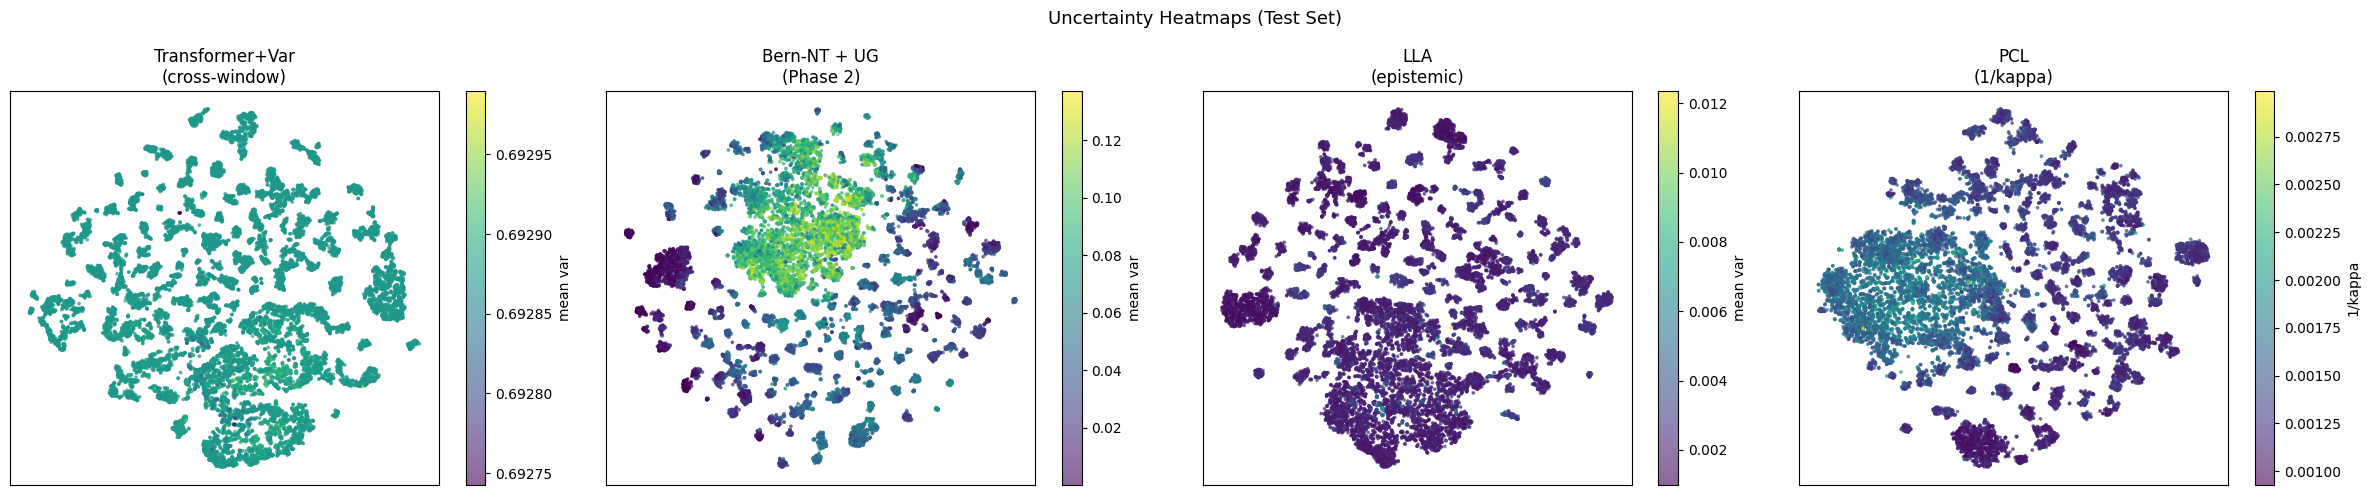

Model                  Mean unc    Std unc        Min        Max
----------------------------------------------------------------
TF+Var                  0.69288    0.00001    0.69274    0.69299
BNT+UG                  0.05285    0.03377    0.00000    0.13704
LLA                     0.00217    0.00059    0.00098    0.01235
PCL 1/k                 0.00138    0.00025    0.00093    0.00299


In [11]:
# Re-compute t-SNE for the models with uncertainty
print('Computing t-SNE for uncertainty heatmaps...')
coords_tf_var = TSNE(**tsne_kw).fit_transform(test_emb_tf_var.mean)
coords_ug_bnt = TSNE(**tsne_kw).fit_transform(test_emb_ug_bnt.mean)
coords_lla    = TSNE(**tsne_kw).fit_transform(test_emb_lla.mean)
coords_pcl    = TSNE(**tsne_kw).fit_transform(test_emb_pcl.mean)

tf_var_unc  = test_emb_tf_var.variance.mean(axis=1)
ug_bnt_unc  = test_emb_ug_bnt.variance.mean(axis=1)
lla_unc     = test_emb_lla.variance.mean(axis=1)
pcl_unc     = 1.0 / np.clip(test_emb_pcl.kappa, 1e-6, None)

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
unc_data = [
    (tf_var_unc,  coords_tf_var,  'Transformer+Var\n(cross-window)',  'mean var'),
    (ug_bnt_unc,  coords_ug_bnt,  'Bern-NT + UG\n(Phase 2)',         'mean var'),
    (lla_unc,     coords_lla,     'LLA\n(epistemic)',                 'mean var'),
    (pcl_unc,     coords_pcl,     'PCL\n(1/kappa)',                   '1/kappa'),
]
for col, (unc, coords, title, cbar_label) in enumerate(unc_data):
    sc = axes[col].scatter(coords[:, 0], coords[:, 1],
                           c=unc, cmap='viridis', s=s, alpha=alpha, rasterized=True)
    plt.colorbar(sc, ax=axes[col], label=cbar_label)
    axes[col].set_title(title)
    axes[col].set_xticks([]); axes[col].set_yticks([])

plt.suptitle('Uncertainty Heatmaps (Test Set)', fontsize=13)
plt.tight_layout()
plt.show()

print(f'{"Model":<20} {"Mean unc":>10} {"Std unc":>10} {"Min":>10} {"Max":>10}')
print('-' * 64)
for name, unc in [('TF+Var', tf_var_unc), ('BNT+UG', ug_bnt_unc), ('LLA', lla_unc), ('PCL 1/k', pcl_unc)]:
    print(f'{name:<20} {unc.mean():>10.5f} {unc.std():>10.5f} {unc.min():>10.5f} {unc.max():>10.5f}')

## 8. Embedding Quality: kNN, Linear Probe & SVM

Supervised probes trained on validation, evaluated on test.
Includes reject-then-classify (discard/garbage modes) for uncertainty-aware models.

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

KNN_K = 5
PROBE_COVERAGES = np.arange(0.1, 1.01, 0.1)
PROBES = [('knn', 'kNN'), ('lin', 'Linear'), ('svm', 'SVM')]

PROBE_MODELS = [
    {
        'name': 'Transformer',
        'train_emb': val_emb_tf.point_estimate,
        'test_emb': test_emb_tf.point_estimate,
        'unc': None,
        'color': 'tab:red', 'marker': '*',
    },
    {
        'name': 'Transformer+Var',
        'train_emb': val_emb_tf_var.point_estimate,
        'test_emb': test_emb_tf_var.point_estimate,
        'unc': test_emb_tf_var.variance.mean(axis=1),
        'color': 'tab:orange', 'marker': 'h',
    },
    {
        'name': 'Bern-NT + UG',
        'train_emb': val_emb_ug_bnt.point_estimate,
        'test_emb': test_emb_ug_bnt.point_estimate,
        'unc': test_emb_ug_bnt.variance.mean(axis=1),
        'color': 'tab:cyan', 'marker': 'v',
    },
    {
        'name': 'Bern + LLA',
        'train_emb': val_emb_lla.point_estimate,
        'test_emb': test_emb_lla.point_estimate,
        'unc': test_emb_lla.variance.mean(axis=1),
        'color': 'tab:green', 'marker': '^',
    },
    {
        'name': 'PCL',
        'train_emb': val_emb_pcl.point_estimate,
        'test_emb': test_emb_pcl.point_estimate,
        'unc': 1.0 / np.clip(test_emb_pcl.kappa, 1e-6, None),
        'color': 'tab:blue', 'marker': 's',
    },
    {
        'name': 'Bern-NT (random)',
        'train_emb': val_emb_bern_nt.point_estimate,
        'test_emb': test_emb_bern_nt.point_estimate,
        'unc': None,
        'color': 'tab:olive', 'marker': 'P',
    },
    {
        'name': 'Bern (random)',
        'train_emb': val_emb_nl.point_estimate,
        'test_emb': test_emb_nl.point_estimate,
        'unc': None,
        'color': 'gray', 'marker': 'x',
    },
]

# Train probes and report full-coverage baselines
print(f"{'Model':>20s}  {'kNN F1':>8s}  {'Lin F1':>8s}  {'SVM F1':>8s}")
print('-' * 52)
for cfg in PROBE_MODELS:
    knn = KNeighborsClassifier(n_neighbors=KNN_K, metric='euclidean')
    knn.fit(cfg['train_emb'], val_labels_num)
    cfg['knn'] = knn

    lin = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=SEED, solver='lbfgs'))
    lin.fit(cfg['train_emb'], val_labels_num)
    cfg['lin'] = lin

    svm = make_pipeline(StandardScaler(), SVC(kernel='rbf', random_state=SEED))
    svm.fit(cfg['train_emb'], val_labels_num)
    cfg['svm'] = svm

    f1s = []
    for key in ['knn', 'lin', 'svm']:
        pred = cfg[key].predict(cfg['test_emb'])
        f1s.append(sklearn.metrics.f1_score(test_labels, pred, average='macro', zero_division=0))
    print(f"{cfg['name']:>20s}  {f1s[0]:>8.4f}  {f1s[1]:>8.4f}  {f1s[2]:>8.4f}")

    if cfg['unc'] is None:
        cfg['unc'] = np.random.RandomState(SEED).rand(len(test_labels))

               Model    kNN F1    Lin F1    SVM F1
----------------------------------------------------
         Transformer    0.5693    0.5940    0.4090
     Transformer+Var    0.5713    0.6195    0.4709
        Bern-NT + UG    0.7165    0.7383    0.6696
          Bern + LLA    0.6426    0.6903    0.5367
                 PCL    0.6144    0.6756    0.6406
    Bern-NT (random)    0.7165    0.7383    0.6696
       Bern (random)    0.6426    0.6903    0.5367


In [13]:
# -- Reject-then-classify: discard & garbage modes --
garbage_label = int(test_labels.max()) + 1
probe_results = {}

for cfg in PROBE_MODELS:
    name = cfg['name']
    order_asc = np.argsort(cfg['unc'])
    N = len(cfg['unc'])

    for probe_key, probe_name in PROBES:
        clf = cfg[probe_key]
        full_pred = clf.predict(cfg['test_emb'])

        for mode in ['discard', 'garbage']:
            records = []
            for cov in PROBE_COVERAGES:
                n_keep = max(1, int(round(N * cov)))
                keep_idx = order_asc[:n_keep]

                if mode == 'discard':
                    pred = full_pred[keep_idx]
                    true = test_labels[keep_idx]
                else:
                    pred = np.full(N, garbage_label, dtype=int)
                    pred[keep_idx] = full_pred[keep_idx]
                    true = test_labels

                acc = float(np.mean(pred == true))
                per_f = sklearn.metrics.f1_score(true, pred, average=None, zero_division=0)
                records.append({
                    'coverage': cov, 'accuracy': acc,
                    'n_F1_gt_09': int(np.sum(per_f > 0.9)),
                    'n_classes': len(per_f),
                })
            probe_results[(probe_key, name, mode)] = records

print('Reject-then-classify computed for all models.')

Reject-then-classify computed for all models.


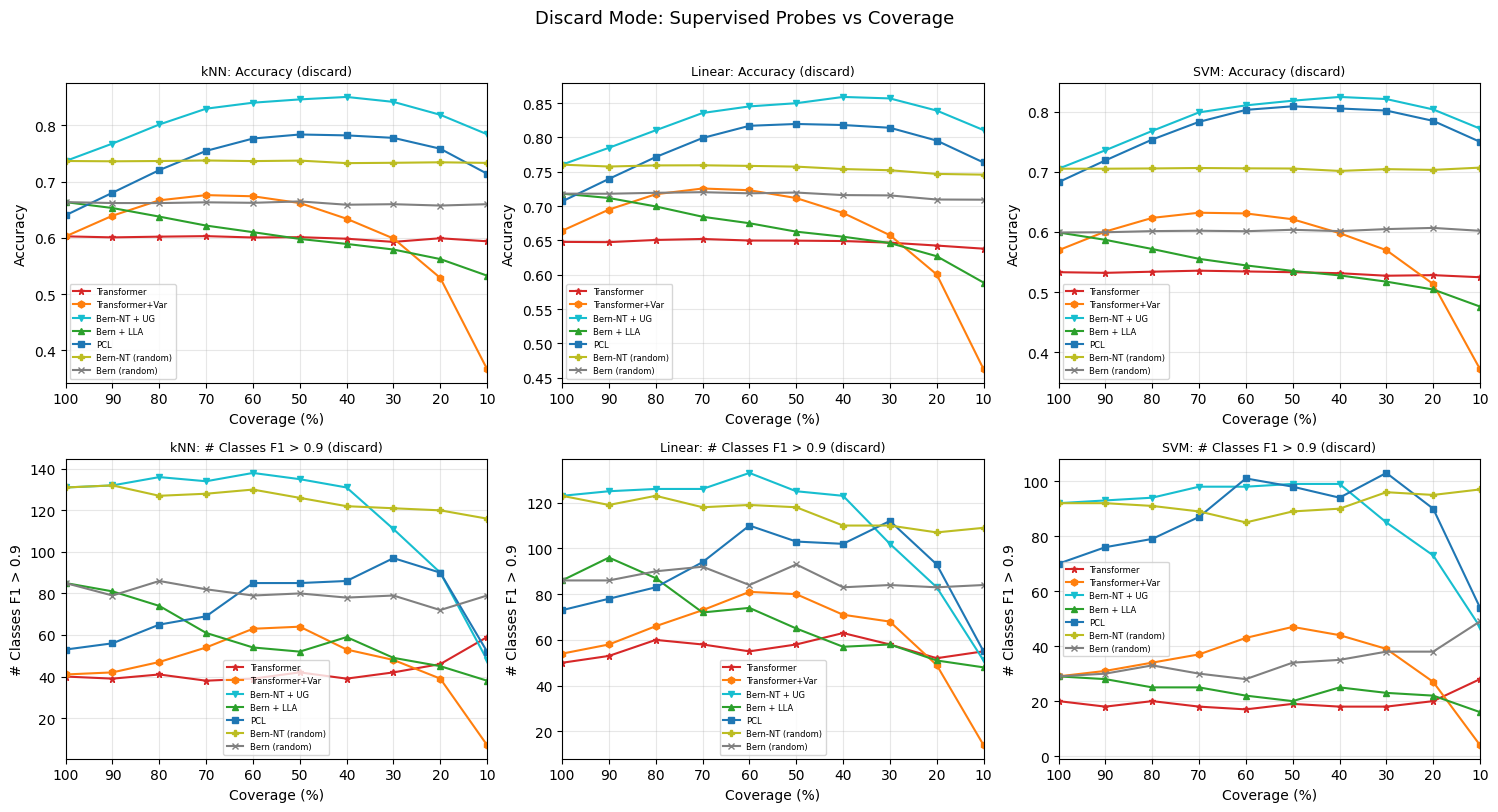

In [14]:
# -- Plot: discard mode --
metrics_to_plot = [
    ('accuracy',    'Accuracy'),
    ('n_F1_gt_09',  '# Classes F1 > 0.9'),
]

fig, axes = plt.subplots(len(metrics_to_plot), 3, figsize=(15, 4 * len(metrics_to_plot)))

for col, (probe_key, probe_label) in enumerate(PROBES):
    for row, (metric_key, ylabel) in enumerate(metrics_to_plot):
        ax = axes[row, col]
        for cfg in PROBE_MODELS:
            name = cfg['name']
            recs = probe_results[(probe_key, name, 'discard')]
            covs = [r['coverage'] for r in recs]
            vals = [r[metric_key] for r in recs]
            ax.plot(np.array(covs) * 100, vals,
                    f"{cfg['marker']}-", color=cfg['color'],
                    label=name, markersize=5)
        ax.set_xlabel('Coverage (%)')
        ax.set_ylabel(ylabel)
        ax.set_title(f'{probe_label}: {ylabel} (discard)', fontsize=9)
        ax.legend(fontsize=6)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(100, 10)

plt.suptitle('Discard Mode: Supervised Probes vs Coverage', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [15]:
# -- Summary table --
print(f"{'Probe':>7s}  {'Model':>20s}  {'Mode':>8s}  {'Cov':>5s}  {'ACC':>7s}  {'F1>.9':>6s}")
print('-' * 65)
for probe_key, probe_label in PROBES:
    for cfg in PROBE_MODELS:
        name = cfg['name']
        for mode in ['discard', 'garbage']:
            recs = probe_results[(probe_key, name, mode)]
            for r in recs:
                if round(r['coverage'], 1) in [0.5, 1.0]:
                    print(f"{probe_label:>7s}  {name:>20s}  {mode:>8s}  "
                          f"{r['coverage']:>5.0%}  {r['accuracy']:>7.4f}  "
                          f"{r['n_F1_gt_09']:>6d}")
    print()

  Probe                 Model      Mode    Cov      ACC   F1>.9
-----------------------------------------------------------------
    kNN           Transformer   discard    50%   0.6012      42
    kNN           Transformer   discard   100%   0.6027      40
    kNN           Transformer   garbage    50%   0.3006       0
    kNN           Transformer   garbage   100%   0.6027      40
    kNN       Transformer+Var   discard    50%   0.6619      64
    kNN       Transformer+Var   discard   100%   0.6026      41
    kNN       Transformer+Var   garbage    50%   0.3310      12
    kNN       Transformer+Var   garbage   100%   0.6026      41
    kNN          Bern-NT + UG   discard    50%   0.8464     135
    kNN          Bern-NT + UG   discard   100%   0.7367     131
    kNN          Bern-NT + UG   garbage    50%   0.4232      66
    kNN          Bern-NT + UG   garbage   100%   0.7367     131
    kNN            Bern + LLA   discard    50%   0.5981      52
    kNN            Bern + LLA   discar

## 9. Window Size Ablation

Test different window sizes to find the sweet spot between positional resolution and statistical stability.

  ws=250: training...


 Training │██████████████████████████████│ 100/100 [1:49:51<00:00, loss=0.034523]


Model saved to: ../../models/notebook/transformer_exp\transformer_ws250.model
  ws=250: 40 windows, kNN F1=0.5846, final loss=0.0345
  ws=500: training...


 Training │██████████████████████████████│ 100/100 [58:10<00:00, loss=0.038241]


Model saved to: ../../models/notebook/transformer_exp\transformer_ws500.model
  ws=500: 20 windows, kNN F1=0.6075, final loss=0.0382
  ws=1000: training...


 Training │██████████████████████████████│ 100/100 [34:21<00:00, loss=0.043480]


Model saved to: ../../models/notebook/transformer_exp\transformer_ws1000.model
  ws=1000: 10 windows, kNN F1=0.6330, final loss=0.0435


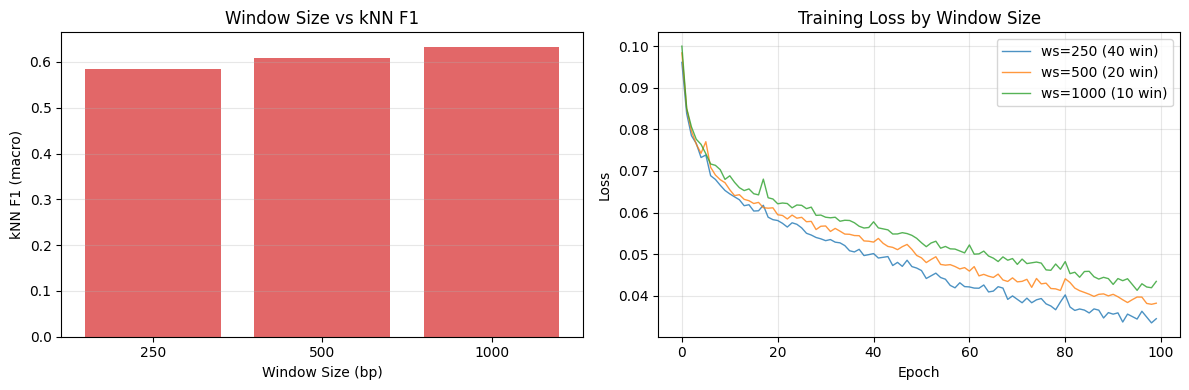

In [16]:
# Window size ablation: train smaller models for fewer epochs as a quick comparison
ABLATION_WINDOW_SIZES = [250, 500, 1000]
ABLATION_EPOCHS = 100  # shorter for ablation
ablation_results = {}

for ws in ABLATION_WINDOW_SIZES:
    abl_path = os.path.join(MODEL_DIR, f'transformer_ws{ws}.model')
    abl_loss_path = os.path.join(MODEL_DIR, f'transformer_ws{ws}_losses.npy')

    set_seed(SEED)

    if os.path.exists(abl_path):
        abl_model = TransformerEmbedder.load(abl_path, device=DEVICE)
        abl_losses = np.load(abl_loss_path) if os.path.exists(abl_loss_path) else None
        print(f'  ws={ws}: loaded from cache')
    else:
        print(f'  ws={ws}: training...')
        def _make_transform(w):
            return lambda seq: feature_extractor.extract_windowed(seq, window_size=w)

        abl_dataset = PairedReadsDataset(
            file_path=TRAIN_CSV, transform_func=_make_transform(ws),
            neg_sample_per_pos=TF_NEG_PER_POS, max_read_num=MAX_PAIRS, seed=SEED, verbose=False,
        )
        abl_model = TransformerEmbedder(
            k=K, dim=DIM, window_size=ws,
            d_model=TF_D_MODEL, nhead=TF_NHEAD, num_layers=TF_NUM_LAYERS,
            dim_feedforward=TF_DIM_FEEDFORWARD, dropout=TF_DROPOUT,
            device=DEVICE, seed=SEED,
        )
        abl_losses = train_contrastive(
            abl_model, abl_dataset, loss_fn=contrastive_loss,
            lr=TF_LR, epochs=ABLATION_EPOCHS, device=DEVICE,
            batch_size=TF_BATCH_SIZE, num_workers=NUM_WORKERS,
            loss_name=TF_LOSS, save_path=abl_path, verbose=True,
        )
        abl_losses = np.array(abl_losses)
        np.save(abl_loss_path, abl_losses)
        del abl_dataset

    # Evaluate
    abl_test_emb = abl_model.embed(test_seqs)
    knn = KNeighborsClassifier(n_neighbors=KNN_K, metric='euclidean')
    abl_val_emb = abl_model.embed(val_seqs)
    knn.fit(abl_val_emb.mean, val_labels_num)
    pred = knn.predict(abl_test_emb.mean)
    f1 = sklearn.metrics.f1_score(test_labels, pred, average='macro', zero_division=0)
    n_windows = 10000 // ws
    ablation_results[ws] = {'f1': f1, 'n_windows': n_windows, 'losses': abl_losses}
    print(f'  ws={ws}: {n_windows} windows, kNN F1={f1:.4f}, final loss={abl_losses[-1]:.4f}')

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ws_list = sorted(ablation_results.keys())
f1_list = [ablation_results[ws]['f1'] for ws in ws_list]
ax1.bar([str(ws) for ws in ws_list], f1_list, color='tab:red', alpha=0.7)
ax1.set_xlabel('Window Size (bp)')
ax1.set_ylabel('kNN F1 (macro)')
ax1.set_title('Window Size vs kNN F1')
ax1.grid(True, alpha=0.3, axis='y')

for ws in ws_list:
    losses = ablation_results[ws]['losses']
    if losses is not None:
        ax2.plot(losses, lw=1, alpha=0.8, label=f'ws={ws} ({ablation_results[ws]["n_windows"]} win)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Training Loss by Window Size')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Save Embeddings

In [17]:
EMB_DIR = os.path.join(MODEL_DIR, 'embeddings')
os.makedirs(EMB_DIR, exist_ok=True)

def save_embedding(emb, name, split):
    data = {'mean': emb.mean}
    if emb.variance is not None:
        data['variance'] = emb.variance
    if hasattr(emb, 'kappa') and emb.kappa is not None:
        data['kappa'] = emb.kappa
    path = os.path.join(EMB_DIR, f'{name}_{split}.npz')
    np.savez(path, **data)

models_to_save = {
    'nl':       (val_emb_nl,      test_emb_nl),
    'tf':       (val_emb_tf,      test_emb_tf),
    'tf_var':   (val_emb_tf_var,  test_emb_tf_var),
    'bern_nt':  (val_emb_bern_nt, test_emb_bern_nt),
    'ug_bnt':   (val_emb_ug_bnt,  test_emb_ug_bnt),
    'pcl':      (val_emb_pcl,     test_emb_pcl),
    'lla':      (val_emb_lla,     test_emb_lla),
}

for name, (val_emb, test_emb) in models_to_save.items():
    save_embedding(val_emb, name, 'val')
    save_embedding(test_emb, name, 'test')
    print(f'{name:>8s}  val={val_emb.mean.shape}  test={test_emb.mean.shape}')

np.save(os.path.join(EMB_DIR, 'val_labels.npy'), val_labels_num)
np.save(os.path.join(EMB_DIR, 'test_labels.npy'), test_labels)
print(f'\nAll saved to {EMB_DIR}/')

      nl  val=(18639, 256)  test=(18639, 256)
      tf  val=(18639, 256)  test=(18639, 256)
  tf_var  val=(18639, 256)  test=(18639, 256)
 bern_nt  val=(18639, 256)  test=(18639, 256)
  ug_bnt  val=(18639, 256)  test=(18639, 256)
     pcl  val=(18639, 256)  test=(18639, 256)
     lla  val=(18639, 256)  test=(18639, 256)

All saved to ../../models/notebook/transformer_exp\embeddings/
